# 05 — Text Classification (NLP)

**Task 1:** Classify listing description into `cat3_slug` (property type) — Logistic Regression / TF-IDF  
**Task 2:** Classify `user_type` (individual vs. agency) — LSTM

---

## Overview

This notebook covers the full NLP pipeline for Persian real estate listing text.

> **⚠ Google Colab Note:** The original notebook was developed and trained on **Google Colab** (GPU).
> The `from google.colab import drive` cell has been commented out.
> To run locally, ensure your data files are in `../data/` and a GPU is available for LSTM training.

### Sub-stages

| Sub-stage | Source notebook | What it does |
|---|---|---|
| 5a — NLP Cleaning | `4-TEXT CLASSIFICATION/1 - CLEANING.ipynb` | Persian text normalisation with Hazm (tokenisation, stemming, stop-word removal), remove noise |
| 5b — Modelling | `4-TEXT CLASSIFICATION/2 - MODELING.ipynb` | TF-IDF Logistic Regression, Bag-of-Words, Word2Vec embeddings, LSTM classifier |

### Libraries
- **Hazm** (Persian NLP toolkit) — tokenisation, stemming, stopwords
- **Scikit-learn** — TF-IDF vectoriser, Logistic Regression, metrics
- **Gensim** — Word2Vec training
- **TensorFlow / Keras** — LSTM model

### Key Results
- **TF-IDF + Logistic Regression** for `cat3_slug`: Accuracy ~87%, Weighted F1 ~85%
- **LSTM** for `user_type`: High recall for the "agency" class; class imbalance addressed with class weights.

### Input
`../data/divar_tehran_nonnum_filled_final.pkl` (or the raw filtered CSV)

---


## Sub-stage 5a — Persian Text Cleaning (Hazm)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from time import sleep

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv(r"C:\Users\kourosh\Desktop\daqiqe Project\1\divar_real_estate_ads.csv")

In [4]:
df.head()

,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
0,temporary-rent,villa,karaj,mehrshahr,2024-08-01 00:00:00,مشاور املاک,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,NaN,NaN,...,NaN,4.0,6,350000.0,1500000.0,3.500000e+09,3500000.0,35.811684,50.936600,500.0
1,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0
2,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,26000000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.703865,51.373459,NaN
3,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,مقطوع,95000000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,residential-sell,apartment-sell,mashhad,emamreza,2024-05-01 00:00:00,مشاور املاک,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 60 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   cat2_slug                   1000000 non-null  object 
 1   cat3_slug                   999999 non-null   object 
 2   city_slug                   999998 non-null   object 
 3   neighborhood_slug           437139 non-null   object 
 4   created_at_month            1000000 non-null  object 
 5   user_type                   288882 non-null   object 
 6   description                 1000000 non-null  object 
 7   title                       999946 non-null   object 
 8   rent_mode                   352994 non-null   object 
 9   rent_value                  351322 non-null   float64
 10  rent_to_single              19 non-null       object 
 11  rent_type                   103961 non-null   object 
 12  price_mode                  573606 non-null   object 
 13

In [6]:
df.describe()

,rent_value,price_value,credit_value,transformable_credit,transformed_credit,transformable_rent,transformed_rent,land_size,building_size,regular_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
count,3.513220e+05,5.683460e+05,3.520950e+05,3.520850e+05,7.240900e+04,3.512480e+05,7.240900e+04,1.863960e+05,9.803940e+05,29870.000000,1.024100e+04,1.806800e+04,1.046300e+04,1.355100e+04,655608.000000,655608.000000,339699.000000
mean,4.102299e+10,1.736537e+10,4.872084e+10,4.872222e+10,8.557025e+09,4.103164e+10,1.619934e+07,4.165480e+03,4.440648e+03,6.557650,1.209785e+10,1.389016e+11,2.355548e+10,3.156551e+10,34.982108,51.629743,465.149147
std,3.807534e+12,5.878739e+11,4.341346e+12,4.341407e+12,2.064576e+12,3.807935e+12,5.217890e+07,1.218927e+05,1.367118e+05,7.698655,1.103482e+12,7.042335e+12,1.542049e+12,2.434942e+12,2.379169,3.160920,125.896250
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,23.626478,40.162369,0.000000
25%,1.111110e+05,1.400000e+09,1.000000e+08,1.000000e+08,2.000000e+08,1.111110e+05,1.000000e+06,1.100000e+02,7.500000e+01,3.000000,5.000000e+04,4.000000e+05,6.000000e+05,5.500000e+05,34.553551,50.677175,500.000000
50%,5.000000e+06,2.840000e+09,2.500000e+08,2.500000e+08,4.000000e+08,5.000000e+06,6.000000e+06,1.950000e+02,1.030000e+02,4.000000,1.000000e+05,8.000000e+05,1.200000e+06,1.100000e+06,35.723312,51.345791,500.000000
75%,1.200000e+07,5.900000e+09,5.000000e+08,5.000000e+08,8.500000e+08,1.200000e+07,1.500000e+07,2.800000e+02,1.650000e+02,7.000000,2.000000e+05,1.600000e+06,2.500000e+06,2.500000e+06,36.307013,51.805291,500.000000
max,1.000000e+15,1.000000e+14,1.000000e+15,1.000000e+15,5.555556e+14,1.000000e+15,3.000000e+09,1.000000e+07,1.000000e+07,50.000000,1.111111e+14,5.006007e+14,1.111111e+14,2.002503e+14,40.358055,74.511620,500.000000


In [7]:
df = df[["cat3_slug","user_type","description","title"]]

In [8]:
df.head()

,cat3_slug,user_type,description,title
0,villa,مشاور املاک,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه
1,apartment-sell,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات
2,apartment-rent,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر
3,office-rent,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری
4,apartment-sell,مشاور املاک,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   cat3_slug    999999 non-null   object
 1   user_type    288882 non-null   object
 2   description  1000000 non-null  object
 3   title        999946 non-null   object
dtypes: object(4)
memory usage: 30.5+ MB


In [10]:
df["not_cleaned"] = df["description"] + " " + df["title"]

In [11]:
df.head()

,cat3_slug,user_type,description,title,not_cleaned
0,villa,مشاور املاک,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...
1,apartment-sell,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...
2,apartment-rent,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,تخلیه پایان ماه آپارتمان ۳ خوابه ۱۳۲ متر
3,office-rent,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...
4,apartment-sell,مشاور املاک,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...


In [12]:
df["not_cleaned"].value_counts

<bound method IndexOpsMixin.value_counts of 0         ۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...
1         دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...
2                  تخلیه پایان ماه آپارتمان ۳ خوابه ۱۳۲ متر
3         فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...
4         هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...
                                ...                        
999995    ~~~مشاورین املاک قبادی~~~\n■جنوبی تک واحدی\n■د...
999996    نوساز     \n\n تک واحدی\n\nشخصی  ساز\n\nروف گا...
999997    سلام ودرود\nفروش منزل مسکونی واقع در خیابان ان...
999998    سویت بدون خواب (روبه دریا و معمولی)\nسویت ۱خوا...
999999    ⚜️املاک بزرگ میلیارد⚜️\n✅️۴۰ متر یک خواب\n✅️نو...
Name: not_cleaned, Length: 1000000, dtype: object>

In [13]:
df["not_cleaned"][2]

'تخلیه پایان ماه آپارتمان ۳ خوابه ۱۳۲ متر'

In [14]:
import re

# حذف کاراکترهای غیر الفبایی و اعداد و تبدیل چند فاصله به یکی
df["not_cleaned"] = df["not_cleaned"].str.replace(r"[\s\W\d]", " ", regex=True)
df["not_cleaned"] = df["not_cleaned"].str.replace(r" +", " ", regex=True)

# نتیجه نهایی
text = df["not_cleaned"]


In [15]:
df.head()

,cat3_slug,user_type,description,title,not_cleaned
0,villa,مشاور املاک,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,متر متر بنا دوبلکس خواب استخر آبگرم داخل سیست...
1,apartment-sell,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,دسترسی عالی به مترو و شریعتی مشاعات تمیز بدون ...
2,apartment-rent,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,تخلیه پایان ماه آپارتمان خوابه متر
3,office-rent,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,فرشته تاپ لوکیشن متر موقعیت اداری یک اتاق مستر...
4,apartment-sell,مشاور املاک,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری,هلدینگ ساختمانی اکبری همراه شما هستیم برای خری...


In [16]:
df["not_cleaned"][2]

'تخلیه پایان ماه آپارتمان خوابه متر'

In [17]:
df["not_cleaned"] = df["not_cleaned"].str.strip()

In [18]:
df["not_cleaned"][2]

'تخلیه پایان ماه آپارتمان خوابه متر'

In [19]:
df["not_cleaned"][6]

'مشاورین املاک سیب کد G با سالها سابقه درخشان در منطقه همراه و پا به پای شما در انجام کلیه امور ملکی ___ واحد اداری متری مناسب تمام مشاغل تخلیه لاین آسانسور ________________ داخل تمیز و مرتب آبدارخانه کف سرامیک کولر گازی فایلهای مشابه و شخصی متناسب با بودجه و سلیقه شما موجود میباشد جامع ترین فایلینگ منطقه باب سلیقه شما ___ آدرس دفتر بهمن خیابان برق میدان گلایول به سمت شهریور بین کوی و مشاور املاک سیب واحداداری متری بهمن برق'

## در کد پایین خواستم اعداد حفظ شوند و بقیه موارد حذف شوند که اعداد هم معنادار باشد

In [20]:
df["not_cleaned2"] = df["description"] + " " + df["title"]
df["not_cleaned2"] = df["not_cleaned2"].str.replace(r"[^۰-۹0-9آ-یءچپژگک]", " ", regex=True)
df["not_cleaned2"] = df["not_cleaned2"].str.replace(r" +", " ", regex=True)
df["not_cleaned2"] = df["not_cleaned2"].str.strip()


In [21]:
df["not_cleaned2"] = df["not_cleaned2"].str.strip()

In [22]:
df["not_cleaned2"][8]

'با سلام املاک بزرگ اتحاد با ۲شعبه فعال با فایلینگ قوی در منطقه بهترین آپارتمان های مناسب و به قیمت منطقه را از ما بخواهید حس خوب خرید ملک را با ما تجربه کنید واحدها واقع در ماهدشت می باشد ۷۸متر روبه نما غرق نور پارکینگ اختصاصی آسانسور انباری سازه مهندسی برند منطقه سند تک برگ لوکیشن تا مرکز خرید و تاکسی ۲دقیقه شرایط پرداخت نقدینگی اولیه شما مبلغ آگهی میباشد ۶۴۰ میلیون وام خرید مسکن ۳۰۰ میلیون رهن مستاجر قیمت کل مبلغ ذکر شده نقدینگی شماست رهن و وام از مبلغ کل کسر شده مشاور و کارشناس امور ملکی شما حسین کریمی ۷۸متری دوبحرنورگیر بازسازی شده شیک سندتک برگ'

In [23]:
df["not_cleaned2"][336]

'۶۵متر ۱ خواب خوش نقشه پاسیو بزرگ و کاربردی لوکیشن دنج و کاملا مسکونی حیاط مشجر متریال برند سازنده مطرح منطقه نوساز کلیدنخورده دسترسی بی نظیر به شریان های اصلی مشاور منطقه ظفر و میرداماد خانم جهانبخش ۶۵متر ظفر کلید نخورده فول لوکیشن دنج'

In [24]:
df["not_cleaned2"][665]

'منزل واقع در خیابان لطفلی خان زند کوچه موزه میباشد نزدیک به تمام نقاط دیدنی وگردشگری منزل از لحاظ بهداشتی در حده عالی میباشد وفقط وفقط به افراد مجاز ودارای مدارک شرعی اجاره داده میشود واز افراد مشکل دار ومجرد با حاشیه اکیدا معذوزیم ضمنا پارکینگ خودرو جلو درب منزل میباشد وکل محوطه دوربین مدار بسته نصب شده اجاره منزل تمیز ومرتب'

In [25]:
df["clean_text"] = df["not_cleaned"]

In [26]:
df.head()

,cat3_slug,user_type,description,title,not_cleaned,not_cleaned2,clean_text
0,villa,مشاور املاک,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,متر متر بنا دوبلکس خواب استخر آبگرم داخل سیستم...,۵۰۰متر ۲۰۰متر بنا دوبلکس ۳خواب استخر آبگرم داخ...,متر متر بنا دوبلکس خواب استخر آبگرم داخل سیستم...
1,apartment-sell,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,دسترسی عالی به مترو و شریعتی مشاعات تمیز بدون ...,دسترسی عالی به مترو و شریعتی مشاعات تمیز بدون ...,دسترسی عالی به مترو و شریعتی مشاعات تمیز بدون ...
2,apartment-rent,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,تخلیه پایان ماه آپارتمان خوابه متر,تخلیه پایان ماه آپارتمان ۳ خوابه ۱۳۲ متر,تخلیه پایان ماه آپارتمان خوابه متر
3,office-rent,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,فرشته تاپ لوکیشن متر موقعیت اداری یک اتاق مستر...,فرشته تاپ لوکیشن ۹۰ متر موقعیت اداری یک اتاق م...,فرشته تاپ لوکیشن متر موقعیت اداری یک اتاق مستر...
4,apartment-sell,مشاور املاک,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری,هلدینگ ساختمانی اکبری همراه شما هستیم برای خری...,هلدینگ ساختمانی اکبری همراه شما هستیم برای خری...,هلدینگ ساختمانی اکبری همراه شما هستیم برای خری...


In [27]:
df = df[["cat3_slug","user_type","clean_text"]]

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   cat3_slug   999999 non-null  object
 1   user_type   288882 non-null  object
 2   clean_text  999946 non-null  object
dtypes: object(3)
memory usage: 22.9+ MB


In [29]:
df.head()

,cat3_slug,user_type,clean_text
0,villa,مشاور املاک,متر متر بنا دوبلکس خواب استخر آبگرم داخل سیستم...
1,apartment-sell,مشاور املاک,دسترسی عالی به مترو و شریعتی مشاعات تمیز بدون ...
2,apartment-rent,NaN,تخلیه پایان ماه آپارتمان خوابه متر
3,office-rent,NaN,فرشته تاپ لوکیشن متر موقعیت اداری یک اتاق مستر...
4,apartment-sell,مشاور املاک,هلدینگ ساختمانی اکبری همراه شما هستیم برای خری...


In [30]:
from hazm import Normalizer

normalizer = Normalizer()

In [31]:
df = df.dropna(subset=['cat3_slug', 'clean_text']).reset_index(drop=True)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999945 entries, 0 to 999944
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   cat3_slug   999945 non-null  object
 1   user_type   288877 non-null  object
 2   clean_text  999945 non-null  object
dtypes: object(3)
memory usage: 22.9+ MB


In [33]:
df["clean_text"] = df["clean_text"].apply(normalizer.normalize)

In [34]:
df["clean_text"]

0         متر متر بنا دوبلکس خواب استخر آبگرم داخل سیستم...
1         دسترسی عالی به مترو و شریعتی مشاعات تمیز بدون ...
2                        تخلیه پایان ماه آپارتمان خوابه متر
3         فرشته تاپ لوکیشن متر موقعیت اداری یک اتاق مستر...
4         هلدینگ ساختمانی اکبری همراه شما هستیم برای خری...
                                ...                        
999940    مشاورین املاک قبادی جنوبی تک واحدی دارای خواب ...
999941    نوساز تک واحدی شخصی ساز روف گاردن میز بیلیارد ...
999942    سلام ودرود فروش منزل مسکونی واقع در خیابان انق...
999943    سویت بدون خواب روبه دریا و معمولی سویت خوابه س...
999944    املاک بزرگ میلیارد متر یک خواب نور و نقشه فوق‌...
Name: clean_text, Length: 999945, dtype: object

In [35]:
from hazm import word_tokenize
df["tokens"] = df["clean_text"].apply(word_tokenize)

In [36]:
df["tokens"][50]

['ملک',
 'یاب',
 'نجف\u200cآباد',
 'اجاره',
 'کد',
 'ملک',
 'محدوده',
 'شریعتی',
 'شرقی',
 'ورودی',
 'مجزا',
 'امتیازات',
 'مجزا',
 'سال',
 'ساخت',
 'کف',
 'موزاییک',
 'پارکینگ',
 'ماشین',
 'زیربنا',
 'گرمایشی',
 'پکیج',
 'سرمایشی',
 'کولرابی',
 'ساعت',
 'کار',
 'و',
 'تماس',
 'صبح',
 'الی',
 'بعد',
 'از',
 'ظهر',
 'الی',
 'جهت',
 'کسب',
 'اطلاعات',
 'بیشتر',
 'فقط',
 'تماس',
 'بگیرید',
 'ملک',
 'یاب',
 'نجف\u200cآباد',
 'ایران',
 'مهر',
 'آدرس',
 'دفتر',
 'خیابان',
 'خرداد',
 'شمالی',
 'نبش',
 'خیابان',
 'جامی',
 'رو',
 'به',
 'روی',
 'شرکت',
 'نفت',
 'منزل',
 'مسکونی',
 'دوخواب',
 'طبقه',
 'اول']

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999945 entries, 0 to 999944
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   cat3_slug   999945 non-null  object
 1   user_type   288877 non-null  object
 2   clean_text  999945 non-null  object
 3   tokens      999945 non-null  object
dtypes: object(4)
memory usage: 30.5+ MB


In [38]:
from hazm import Stemmer

stemmer = Stemmer()
df["stems"] = df["tokens"].apply(lambda words: [stemmer.stem(w) for w in words])


In [39]:
df["stems"][:5]

0    [, , بنا, دوبلکس, خواب, استخر, آبگر, داخل, سیس...
1    [دسترس, عال, به, مترو, و, شریعت, مشاع, تمیز, ب...
2                      [تخلیه, پا, ماه, آپار, خوابه, ]
3    [فرشته, تاپ, لوکیشن, , موقع, ادار, یک, اتاق, م...
4    [هلدینگ, ساختمان, اکبر, همراه, شما, هست, برا, ...
Name: stems, dtype: object

In [40]:
df.head()

,cat3_slug,user_type,clean_text,tokens,stems
0,villa,مشاور املاک,متر متر بنا دوبلکس خواب استخر آبگرم داخل سیستم...,"[متر, متر, بنا, دوبلکس, خواب, استخر, آبگرم, دا...","[, , بنا, دوبلکس, خواب, استخر, آبگر, داخل, سیس..."
1,apartment-sell,مشاور املاک,دسترسی عالی به مترو و شریعتی مشاعات تمیز بدون ...,"[دسترسی, عالی, به, مترو, و, شریعتی, مشاعات, تم...","[دسترس, عال, به, مترو, و, شریعت, مشاع, تمیز, ب..."
2,apartment-rent,NaN,تخلیه پایان ماه آپارتمان خوابه متر,"[تخلیه, پایان, ماه, آپارتمان, خوابه, متر]","[تخلیه, پا, ماه, آپار, خوابه, ]"
3,office-rent,NaN,فرشته تاپ لوکیشن متر موقعیت اداری یک اتاق مستر...,"[فرشته, تاپ, لوکیشن, متر, موقعیت, اداری, یک, ا...","[فرشته, تاپ, لوکیشن, , موقع, ادار, یک, اتاق, م..."
4,apartment-sell,مشاور املاک,هلدینگ ساختمانی اکبری همراه شما هستیم برای خری...,"[هلدینگ, ساختمانی, اکبری, همراه, شما, هستیم, ب...","[هلدینگ, ساختمان, اکبر, همراه, شما, هست, برا, ..."


In [41]:
# read stopwords
stopwords = pd.read_csv('Stopwords.csv', header=0)

In [42]:
stopwords.head

<bound method NDFrame.head of          word
0          آخ
1         آخر
2       آخرها
3         آخه
4     آدمهاست
...       ...
1142    گیرند
1143     گیری
1144    گیرید
1145    گیریم
1146       یا

[1147 rows x 1 columns]>

In [43]:
stops = set(stopwords['word'])


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999945 entries, 0 to 999944
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   cat3_slug   999945 non-null  object
 1   user_type   288877 non-null  object
 2   clean_text  999945 non-null  object
 3   tokens      999945 non-null  object
 4   stems       999945 non-null  object
dtypes: object(5)
memory usage: 38.1+ MB


In [45]:
df["clean_text1"] = df["stems"].apply(lambda word_list: [w for w in word_list if w not in stops])


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999945 entries, 0 to 999944
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   cat3_slug    999945 non-null  object
 1   user_type    288877 non-null  object
 2   clean_text   999945 non-null  object
 3   tokens       999945 non-null  object
 4   stems        999945 non-null  object
 5   clean_text1  999945 non-null  object
dtypes: object(6)
memory usage: 45.8+ MB


In [47]:
df["clean_text1"][44]

['رهن',
 'اجاره',
 'سوئ',
 'اتاق',
 'طبقه',
 'همکف',
 'اتاق',
 'خانواده',
 'سال',
 'مشکل',
 'اب',
 'برق',
 'گاز',
 'اشتراک',
 'اس',
 'برحسب',
 'تعداد',
 'نفر',
 'محاسبه',
 'می\u200cشود',
 'دارا',
 'سرویس',
 'بهداشت',
 'حما',
 'آشپزخانه',
 'می\u200cباشد',
 'امک',
 'پارکینگ',
 'منزل',
 'مجرد',
 'اجاره',
 'داده_نمی\u200cشود',
 'آدرس',
 'خیاب',
 'ربابه',
 'کمال',
 'ساز',
 'امور',
 'مالیات',
 'مشاور',
 'املاک',
 'ایران\u200cزمین',
 'اجاره',
 'سوئ',
 'اتاق',
 'همکف']

In [48]:
df.head()

,cat3_slug,user_type,clean_text,tokens,stems,clean_text1
0,villa,مشاور املاک,متر متر بنا دوبلکس خواب استخر آبگرم داخل سیستم...,"[متر, متر, بنا, دوبلکس, خواب, استخر, آبگرم, دا...","[, , بنا, دوبلکس, خواب, استخر, آبگر, داخل, سیس...","[, , بنا, دوبلکس, خواب, استخر, آبگر, سیس, صوت,..."
1,apartment-sell,مشاور املاک,دسترسی عالی به مترو و شریعتی مشاعات تمیز بدون ...,"[دسترسی, عالی, به, مترو, و, شریعتی, مشاعات, تم...","[دسترس, عال, به, مترو, و, شریعت, مشاع, تمیز, ب...","[دسترس, عال, مترو, شریعت, مشاع, تمیز, ایراد, آ..."
2,apartment-rent,NaN,تخلیه پایان ماه آپارتمان خوابه متر,"[تخلیه, پایان, ماه, آپارتمان, خوابه, متر]","[تخلیه, پا, ماه, آپار, خوابه, ]","[تخلیه, پا, ماه, آپار, خوابه, ]"
3,office-rent,NaN,فرشته تاپ لوکیشن متر موقعیت اداری یک اتاق مستر...,"[فرشته, تاپ, لوکیشن, متر, موقعیت, اداری, یک, ا...","[فرشته, تاپ, لوکیشن, , موقع, ادار, یک, اتاق, م...","[فرشته, تاپ, لوکیشن, , موقع, ادار, اتاق, مس, د..."
4,apartment-sell,مشاور املاک,هلدینگ ساختمانی اکبری همراه شما هستیم برای خری...,"[هلدینگ, ساختمانی, اکبری, همراه, شما, هستیم, ب...","[هلدینگ, ساختمان, اکبر, همراه, شما, هست, برا, ...","[هلدینگ, ساختمان, اکبر, همراه, خرید, مطمئن, کل..."


In [49]:
df_final = df[["cat3_slug", "user_type", "clean_text1"]]

In [50]:
df_final.head()

,cat3_slug,user_type,clean_text1
0,villa,مشاور املاک,"[, , بنا, دوبلکس, خواب, استخر, آبگر, سیس, صوت,..."
1,apartment-sell,مشاور املاک,"[دسترس, عال, مترو, شریعت, مشاع, تمیز, ایراد, آ..."
2,apartment-rent,NaN,"[تخلیه, پا, ماه, آپار, خوابه, ]"
3,office-rent,NaN,"[فرشته, تاپ, لوکیشن, , موقع, ادار, اتاق, مس, د..."
4,apartment-sell,مشاور املاک,"[هلدینگ, ساختمان, اکبر, همراه, خرید, مطمئن, کل..."


In [51]:
df_final["clean_text"] = df_final["clean_text1"]

In [52]:
df_final.head()

,cat3_slug,user_type,clean_text1,clean_text
0,villa,مشاور املاک,"[, , بنا, دوبلکس, خواب, استخر, آبگر, سیس, صوت,...","[, , بنا, دوبلکس, خواب, استخر, آبگر, سیس, صوت,..."
1,apartment-sell,مشاور املاک,"[دسترس, عال, مترو, شریعت, مشاع, تمیز, ایراد, آ...","[دسترس, عال, مترو, شریعت, مشاع, تمیز, ایراد, آ..."
2,apartment-rent,NaN,"[تخلیه, پا, ماه, آپار, خوابه, ]","[تخلیه, پا, ماه, آپار, خوابه, ]"
3,office-rent,NaN,"[فرشته, تاپ, لوکیشن, , موقع, ادار, اتاق, مس, د...","[فرشته, تاپ, لوکیشن, , موقع, ادار, اتاق, مس, د..."
4,apartment-sell,مشاور املاک,"[هلدینگ, ساختمان, اکبر, همراه, خرید, مطمئن, کل...","[هلدینگ, ساختمان, اکبر, همراه, خرید, مطمئن, کل..."


In [53]:
df_final.drop(["clean_text1"], axis=1,inplace=True)

In [54]:
df_final.head()

,cat3_slug,user_type,clean_text
0,villa,مشاور املاک,"[, , بنا, دوبلکس, خواب, استخر, آبگر, سیس, صوت,..."
1,apartment-sell,مشاور املاک,"[دسترس, عال, مترو, شریعت, مشاع, تمیز, ایراد, آ..."
2,apartment-rent,NaN,"[تخلیه, پا, ماه, آپار, خوابه, ]"
3,office-rent,NaN,"[فرشته, تاپ, لوکیشن, , موقع, ادار, اتاق, مس, د..."
4,apartment-sell,مشاور املاک,"[هلدینگ, ساختمان, اکبر, همراه, خرید, مطمئن, کل..."


In [55]:
df_final.to_csv("tehran_text_full_tamiz.csv", index=False)

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from time import sleep

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
data_path = "/content/drive/MyDrive/Colab Notebooks/daqiqe/text_full_tamiz.csv"  # فایل CSV به عنوان مثال
df = pd.read_csv(data_path)
print(df.head())


        cat3_slug    user_type  \
0           villa  مشاور املاک   
1  apartment-sell  مشاور املاک   
2  apartment-rent          NaN   
3     office-rent          NaN   
4  apartment-sell  مشاور املاک   

                                          clean_text  
0  ['', '', 'بنا', 'دوبلکس', 'خواب', 'استخر', 'آب...  
1  ['دسترس', 'عال', 'مترو', 'شریعت', 'مشاع', 'تمی...  
2        ['تخلیه', 'پا', 'ماه', 'آپار', 'خوابه', '']  
3  ['فرشته', 'تاپ', 'لوکیشن', '', 'موقع', 'ادار',...  
4  ['هلدینگ', 'ساختمان', 'اکبر', 'همراه', 'خرید',...  


In [8]:
df.describe()

,cat3_slug,user_type,clean_text
count,999945,288877,999945
unique,16,2,994046
top,apartment-sell,مشاور املاک,"['قیم', 'واقع', 'می\u200cباشد', 'ویلا', 'باغ',..."
freq,303372,256006,193


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999945 entries, 0 to 999944
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   cat3_slug   999945 non-null  object
 1   user_type   288877 non-null  object
 2   clean_text  999945 non-null  object
dtypes: object(3)
memory usage: 22.9+ MB


In [4]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 10000
max_len = 50  # You can adjust this based on text lengths

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df["clean_text"].astype(str))
sequences = tokenizer.texts_to_sequences(df["clean_text"].astype(str))
X_emb = pad_sequences(sequences, maxlen=max_len)

print("Embedding feature shape:", X_emb.shape)


Embedding feature shape: (999945, 50)


۱. Sampling و تقسیم داده

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Sample 40% of the data
df_sampled = df.sample(frac=0.4, random_state=42)
texts = df_sampled["clean_text"].astype(str).tolist()
y = df_sampled["cat3_slug"]


۲. ویژگی‌سازی با BoW و TF-IDF

In [14]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

max_features = 10000

# Bag of Words
vectorizer_bow = CountVectorizer(max_features=max_features)
X_bow = vectorizer_bow.fit_transform(texts)

# TF-IDF
vectorizer_tfidf = TfidfVectorizer(max_features=max_features)
X_tfidf = vectorizer_tfidf.fit_transform(texts)


۳. تقسیم آموزش و تست (هر دو روش مشابه)


In [15]:
# For BoW
X_train_bow, X_test_bow, y_train, y_test = train_test_split(
    X_bow, y, test_size=0.2, random_state=42
)

# For TF-IDF
X_train_tfidf, X_test_tfidf, _, _ = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)


۴. مدل‌سازی با سه مدل (برای هر روش جداگانه)

In [16]:
from sklearn.linear_model import LogisticRegression

lr_bow = LogisticRegression(max_iter=100)
lr_bow.fit(X_train_bow, y_train)
y_pred_bow = lr_bow.predict(X_test_bow)

lr_tfidf = LogisticRegression(max_iter=100)
lr_tfidf.fit(X_train_tfidf, y_train)
y_pred_tfidf = lr_tfidf.predict(X_test_tfidf)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [29]:
from sklearn.ensemble import RandomForestClassifier

# استفاده از پارامترهای تنظیم‌شده برای افزایش سرعت
fast_rf_bow = RandomForestClassifier(
    n_estimators=20,      # تعداد کم درخت‌ها برای سرعت اولیه
    max_depth=10,         # محدود کردن عمق هر درخت
    n_jobs=-1,            # موازی‌سازی
    random_state=42,
    verbose=1             # نمایش روند اجرا (اختیاری)
)
fast_rf_bow.fit(X_train_bow, y_train)
y_pred_bow_rf_fast = fast_rf_bow.predict(X_test_bow)

fast_rf_tfidf = RandomForestClassifier(
    n_estimators=20,
    max_depth=10,
    n_jobs=-1,
    random_state=42,
    verbose=1
)
fast_rf_tfidf.fit(X_train_tfidf, y_train)
y_pred_tfidf_rf_fast = fast_rf_tfidf.predict(X_test_tfidf)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  20 out of  20 | elapsed:    5.7s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  20 out of  20 | elapsed:    0.5s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  20 out of  20 | elapsed:    8.6s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  20 out of  20 | elapsed:    0.3s finished


**خط پاییت tuned هستش**

In [30]:
from sklearn.ensemble import RandomForestClassifier

rf_bow = RandomForestClassifier(
    n_estimators=50,           # نه خیلی کم، نه خیلی زیاد
    max_depth=20,              # عمق متوسط، قابل تغییر
    min_samples_split=5,       # گره جدید با حداقل 5 نمونه
    min_samples_leaf=2,        # هر برگ حداقل 2 نمونه داشته باشد
    max_features='sqrt',       # برای تقسیم از جذر تعداد ویژگی‌ها استفاده کن
    class_weight='balanced',   # مقابله با کلاس‌های نامتوازن
    n_jobs=-1,
    random_state=42,
    verbose=1
)
rf_bow.fit(X_train_bow, y_train)
y_pred_bow_rf_tuned = rf_bow.predict(X_test_bow)

rf_tfidf = RandomForestClassifier(
    n_estimators=50,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
rf_tfidf.fit(X_train_tfidf, y_train)
y_pred_tfidf_rf_tuned = rf_tfidf.predict(X_test_tfidf)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:  1.2min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    2.1s
[Parallel(n_jobs=2)]: Done  50 out of  50 | elapsed:    2.2s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:   51.5s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:   54.9s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.6s
[Parallel(n_jobs=2)]: Done  50 out of  50 | elapsed:    0.7s finished


In [20]:
from sklearn.naive_bayes import MultinomialNB

nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train)
y_pred_bow_nb = nb_bow.predict(X_test_bow)

nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)
y_pred_tfidf_nb = nb_tfidf.predict(X_test_tfidf)


۵. گزارش نتایج و مقایسه (هر دو روش)

In [31]:
from sklearn.metrics import classification_report

print("=== Bag of Words (BoW) ===")
print("Logistic Regression:\n", classification_report(y_test, y_pred_bow))
print("Random Forest Fast:\n", classification_report(y_test, y_pred_bow_rf_fast))
print("Random Forest Tuned:\n", classification_report(y_test, y_pred_bow_rf_tuned))
print("Naive Bayes:\n", classification_report(y_test, y_pred_bow_nb))

print("\n=== TF-IDF ===")
print("Logistic Regression:\n", classification_report(y_test, y_pred_tfidf))
print("Random Forest Fast:\n", classification_report(y_test, y_pred_tfidf_rf_fast))
print("Random Forest Tuned:\n", classification_report(y_test, y_pred_tfidf_rf_tuned))
print("Naive Bayes:\n", classification_report(y_test, y_pred_tfidf_nb))


=== Bag of Words (BoW) ===
Logistic Regression:
                                     precision    recall  f1-score   support

                    apartment-rent       0.80      0.81      0.80     16809
                    apartment-sell       0.86      0.87      0.86     24241
                  house-villa-rent       0.75      0.73      0.74      5269
                  house-villa-sell       0.84      0.83      0.83      9783
industry-agriculture-business-rent       0.74      0.68      0.71       745
industry-agriculture-business-sell       0.57      0.32      0.41      1042
                       office-rent       0.80      0.76      0.78      1724
                       office-sell       0.65      0.47      0.54       421
                       partnership       0.81      0.62      0.70       279
                          plot-old       0.86      0.90      0.88     10621
                           presell       0.71      0.59      0.65      1201
                         shop-rent    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Random Forest Fast:
                                     precision    recall  f1-score   support

                    apartment-rent       0.54      0.24      0.34     16809
                    apartment-sell       0.42      0.99      0.59     24241
                  house-villa-rent       0.88      0.01      0.01      5269
                  house-villa-sell       0.86      0.26      0.40      9783
industry-agriculture-business-rent       0.00      0.00      0.00       745
industry-agriculture-business-sell       0.00      0.00      0.00      1042
                       office-rent       0.00      0.00      0.00      1724
                       office-sell       0.00      0.00      0.00       421
                       partnership       0.00      0.00      0.00       279
                          plot-old       0.73      0.79      0.76     10621
                           presell       1.00      0.01      0.01      1201
                         shop-rent       0.88      0.09      0.17 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Random Forest Fast:
                                     precision    recall  f1-score   support

                    apartment-rent       0.59      0.25      0.35     16809
                    apartment-sell       0.41      0.99      0.58     24241
                  house-villa-rent       0.94      0.01      0.01      5269
                  house-villa-sell       0.89      0.24      0.38      9783
industry-agriculture-business-rent       0.00      0.00      0.00       745
industry-agriculture-business-sell       0.00      0.00      0.00      1042
                       office-rent       0.00      0.00      0.00      1724
                       office-sell       0.00      0.00      0.00       421
                       partnership       0.00      0.00      0.00       279
                          plot-old       0.74      0.77      0.75     10621
                           presell       1.00      0.01      0.01      1201
                         shop-rent       0.84      0.18      0.29 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Naive Bayes:
                                     precision    recall  f1-score   support

                    apartment-rent       0.71      0.69      0.70     16809
                    apartment-sell       0.72      0.87      0.79     24241
                  house-villa-rent       0.63      0.58      0.60      5269
                  house-villa-sell       0.76      0.65      0.70      9783
industry-agriculture-business-rent       0.78      0.43      0.56       745
industry-agriculture-business-sell       0.63      0.11      0.19      1042
                       office-rent       0.78      0.52      0.63      1724
                       office-sell       0.00      0.00      0.00       421
                       partnership       0.94      0.05      0.10       279
                          plot-old       0.74      0.89      0.81     10621
                           presell       0.66      0.32      0.43      1201
                         shop-rent       0.75      0.84      0.80      37

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [32]:
from sklearn.metrics import accuracy_score, f1_score

def eval_model(y_true, y_pred, model_name, vec_name):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    print(f"{model_name} ({vec_name}) -> Accuracy: {acc:.3f}, Weighted F1: {f1:.3f}")

print("==== Simple results summary ====")
eval_model(y_test, y_pred_bow,             "LogReg",          "BoW")
eval_model(y_test, y_pred_bow_rf_fast,      "RandomForest",    "BoW")
eval_model(y_test, y_pred_tfidf_rf_tuned,    "RandomForest+",   "BoW")
eval_model(y_test, y_pred_bow_nb,          "NaiveBayes",      "BoW")

print("==========")
eval_model(y_test, y_pred_tfidf,           "LogReg",          "TF-IDF")
eval_model(y_test, y_pred_tfidf_rf_fast,    "RandomForest",    "TF-IDF")
eval_model(y_test, y_pred_tfidf_rf_tuned,  "RandomForest+",   "TF-IDF")
eval_model(y_test, y_pred_tfidf_nb,        "NaiveBayes",      "TF-IDF")


==== Simple results summary ====
LogReg (BoW) -> Accuracy: 0.825, Weighted F1: 0.823
RandomForest (BoW) -> Accuracy: 0.495, Weighted F1: 0.410
RandomForest+ (BoW) -> Accuracy: 0.698, Weighted F1: 0.716
NaiveBayes (BoW) -> Accuracy: 0.749, Weighted F1: 0.755
LogReg (TF-IDF) -> Accuracy: 0.829, Weighted F1: 0.826
RandomForest (TF-IDF) -> Accuracy: 0.494, Weighted F1: 0.413
RandomForest+ (TF-IDF) -> Accuracy: 0.698, Weighted F1: 0.716
NaiveBayes (TF-IDF) -> Accuracy: 0.729, Weighted F1: 0.715


In [33]:
!pip install gensim


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 11.2 MB/s eta 0:00:00


In [34]:
from gensim.models import Word2Vec

In [35]:
# فرض: clean_text کاملاً پیش‌پردازش شده و هر رکورد یک جمله است
sentences = [str(text).split() for text in df_sampled["clean_text"]]


۳. آموزش مدل Word2Vec


In [36]:
w2v_model = Word2Vec(
    sentences,
    vector_size=100,      # ابعاد بردارها (قابل تغییر)
    window=5,             # پنجره متن
    min_count=2,          # حداقل تکرار کلمه
    workers=4,            # تعداد هسته‌ها
    sg=1                  # استراتژی Skip-gram (دقیق‌تر در مسائل دسته‌بندی بزرگ)
)


ساخت بردار

In [37]:
def sentence_vector(sentence, model):
    words = sentence.split()
    word_vecs = [model.wv[w] for w in words if w in model.wv]
    if len(word_vecs) == 0:
        return np.zeros(model.vector_size)
    else:
        return np.mean(word_vecs, axis=0)

X_w2v = np.array([sentence_vector(s, w2v_model) for s in df_sampled["clean_text"].astype(str)])


train & test

In [38]:
from sklearn.model_selection import train_test_split

X_train_w2v, X_test_w2v, y_train, y_test = train_test_split(
    X_w2v, y, test_size=0.2, random_state=42
)

from sklearn.linear_model import LogisticRegression
logreg_w2v = LogisticRegression(max_iter=100)
logreg_w2v.fit(X_train_w2v, y_train)
y_pred_w2v = logreg_w2v.predict(X_test_w2v)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [39]:
rf_w2v = RandomForestClassifier(
    n_estimators=50,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_w2v.fit(X_train_w2v, y_train)
y_pred_rf_w2v = rf_w2v.predict(X_test_w2v)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:  7.5min
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:  8.1min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    1.1s
[Parallel(n_jobs=2)]: Done  50 out of  50 | elapsed:    1.2s finished


In [40]:
print("==== Simple results summary (Word2Vec) ====")
eval_model(y_test, y_pred_w2v,        "LogReg", "Word2Vec")
eval_model(y_test, y_pred_rf_w2v,     "RandomForest", "Word2Vec")

==== Simple results summary (Word2Vec) ====
LogReg (Word2Vec) -> Accuracy: 0.778, Weighted F1: 0.774
RandomForest (Word2Vec) -> Accuracy: 0.737, Weighted F1: 0.734


In [41]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 10000
max_len = 50

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df_sampled["clean_text"].astype(str))

sequences = tokenizer.texts_to_sequences(df_sampled["clean_text"].astype(str))
X_seq = pad_sequences(sequences, maxlen=max_len)


from sklearn.preprocessing import LabelEncoder

y = df_sampled["cat3_slug"]
label_enc = LabelEncoder()
y_encoded = label_enc.fit_transform(y)


In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

num_classes = len(label_enc.classes_)

model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

print(model.summary())


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_seq, y_encoded, test_size=0.2, random_state=42)

model.fit(X_train, y_train,
          epochs=10,
          batch_size=32,
          validation_data=(X_test, y_test))


Epoch 1/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 944s 93ms/step - accuracy: 0.7259 - loss: 0.8017 - val_accuracy: 0.8288 - val_loss: 0.4717
Epoch 2/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 932s 93ms/step - accuracy: 0.8335 - loss: 0.4703 - val_accuracy: 0.8371 - val_loss: 0.4466
Epoch 3/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 927s 93ms/step - accuracy: 0.8491 - loss: 0.4181 - val_accuracy: 0.8402 - val_loss: 0.4410
Epoch 4/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 933s 93ms/step - accuracy: 0.8605 - loss: 0.3836 - val_accuracy: 0.8394 - val_loss: 0.4532
Epoch 5/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 925s 92ms/step - accuracy: 0.8692 - loss: 0.3588 - val_accuracy: 0.8393 - val_loss: 0.4670
Epoch 6/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 922s 92ms/step - accuracy: 0.8755 - loss: 0.3390 - val_accuracy: 0.8377 - val_loss: 0.4690
Epoch 7/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 922s 92ms/step - accuracy: 0.8824 - loss: 0.3180 - val_accuracy: 0.8359 - val_loss: 0.4914
Epoch 8/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 986s 93ms/s

قسمت سوال 3 که با
LSTM

پیش میبریم

In [6]:

user_type_counts = df_sampled["user_type"].value_counts(dropna=False)
print(user_type_counts)

user_type
NaN            284587
مشاور املاک    102043
شخصی            13348
Name: count, dtype: int64


1. حذف رکوردهای Null و آماده‌سازی لیبل‌ها

In [8]:

filtered_df = df_sampled[df_sampled["user_type"].notnull()]
texts = filtered_df["clean_text"].astype(str).tolist()
labels = filtered_df["user_type"].astype(str).tolist()

2. برچسب‌گذاری عددی


In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(labels)


3. توکنایز و تبدیل به بردار عددی


In [10]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 10000
max_len = 50

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
X_seq = pad_sequences(sequences, maxlen=max_len)


4. تقسیم آموزش/آزمون

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y, test_size=0.2, random_state=42, stratify=y
)


5. محاسبه class_weight (دقیق و بدون خطا)


In [12]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print("class_weight:", class_weight_dict)


class_weight: {0: np.float64(4.32253230942124), 1: np.float64(0.5654016708724307)}


6. ساخت و آموزش مدل LSTM با class_weight

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

num_classes = len(le.classes_)

model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=256,
    validation_data=(X_test, y_test),
    class_weight=class_weight_dict     # راهکار عدم توازن!
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
361/361 ━━━━━━━━━━━━━━━━━━━━ 109s 281ms/step - accuracy: 0.8186 - loss: 0.4309 - val_accuracy: 0.8955 - val_loss: 0.2668
Epoch 2/5
361/361 ━━━━━━━━━━━━━━━━━━━━ 142s 280ms/step - accuracy: 0.8940 - loss: 0.2934 - val_accuracy: 0.9084 - val_loss: 0.2313
Epoch 3/5
361/361 ━━━━━━━━━━━━━━━━━━━━ 110s 306ms/step - accuracy: 0.9028 - loss: 0.2490 - val_accuracy: 0.8775 - val_loss: 0.2911
Epoch 4/5
361/361 ━━━━━━━━━━━━━━━━━━━━ 101s 280ms/step - accuracy: 0.9015 - loss: 0.2196 - val_accuracy: 0.8735 - val_loss: 0.2957
Epoch 5/5
361/361 ━━━━━━━━━━━━━━━━━━━━ 143s 282ms/step - accuracy: 0.9068 - loss: 0.1959 - val_accuracy: 0.8946 - val_loss: 0.2761


7. ارزیابی مدل و بررسی دقت هر کلاس

In [14]:
from sklearn.metrics import classification_report

y_pred_lstm = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_pred_lstm, target_names=le.classes_))


722/722 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step
              precision    recall  f1-score   support

        شخصی       0.53      0.81      0.64      2670
 مشاور املاک       0.97      0.91      0.94     20409

    accuracy                           0.89     23079
   macro avg       0.75      0.86      0.79     23079
weighted avg       0.92      0.89      0.90     23079



8. پیش‌بینی user_type برای نمونه‌های Null


In [15]:
unlabeled = df_sampled[df_sampled["user_type"].isnull()]
texts_unlabeled = unlabeled["clean_text"].astype(str).tolist()
X_seq_unlabeled = pad_sequences(tokenizer.texts_to_sequences(texts_unlabeled), maxlen=max_len)

pred_user_type = le.inverse_transform(np.argmax(model.predict(X_seq_unlabeled), axis=1))
df_sampled.loc[unlabeled.index, "predicted_user_type"] = pred_user_type


8894/8894 ━━━━━━━━━━━━━━━━━━━━ 136s 15ms/step


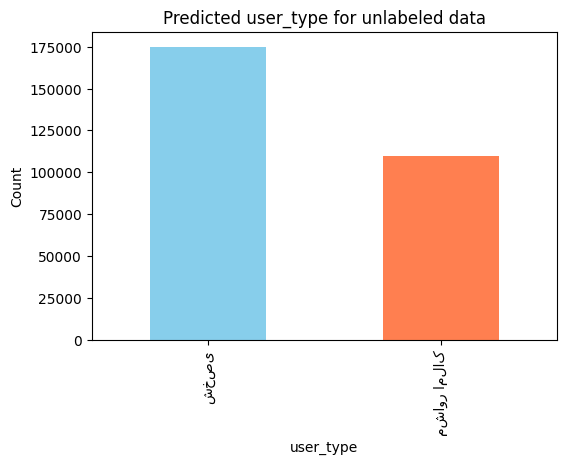

In [16]:
import matplotlib.pyplot as plt

# شمارش فراوانی user_type پیش‌بینی شده
pred_counts = df_sampled.loc[df_sampled['predicted_user_type'].notnull(), 'predicted_user_type'].value_counts()

plt.figure(figsize=(6,4))
pred_counts.plot(kind='bar', color=['skyblue','coral'])
plt.title('Predicted user_type for unlabeled data')
plt.ylabel('Count')
plt.xlabel('user_type')
plt.show()


In [17]:
pred_percent = pred_counts / pred_counts.sum() * 100
print(pred_percent)

predicted_user_type
شخصی           61.516513
مشاور املاک    38.483487
Name: count, dtype: float64


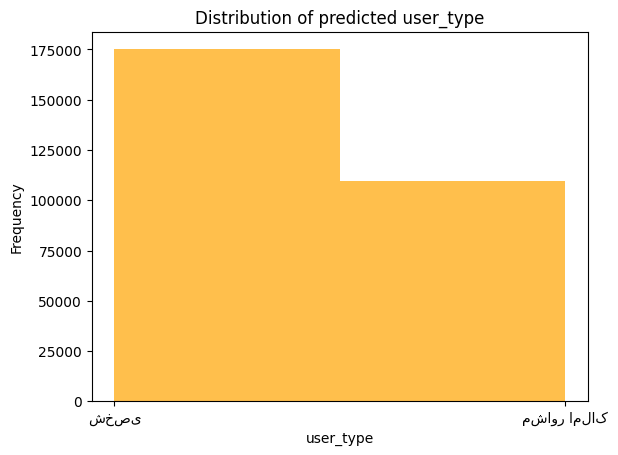

In [18]:
plt.hist(df_sampled['predicted_user_type'].dropna(), bins=2, color='orange', alpha=0.7)
plt.title('Distribution of predicted user_type')
plt.xlabel('user_type')
plt.ylabel('Frequency')
plt.show()


In [19]:
counts = df_sampled.loc[df_sampled['predicted_user_type'].notnull(), 'predicted_user_type'].value_counts()
print(counts)


predicted_user_type
شخصی           175068
مشاور املاک    109519
Name: count, dtype: int64


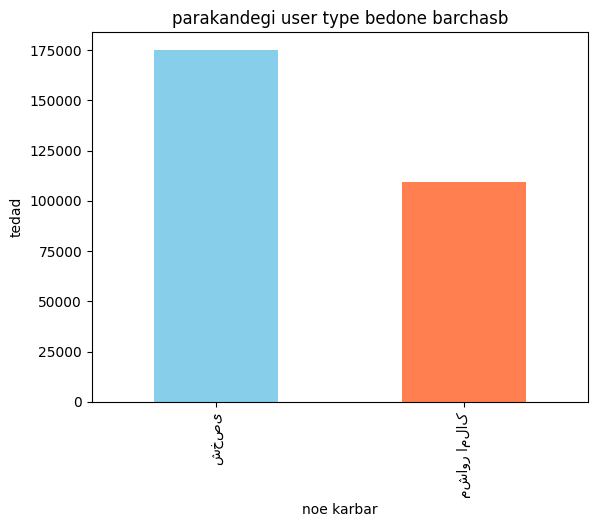

In [21]:
import matplotlib.pyplot as plt

counts.plot(kind='bar', color=['skyblue','coral'])
plt.title('parakandegi user type bedone barchasb')
plt.xlabel('noe karbar')
plt.ylabel('tedad')
plt.show()
